<div style="text-align: center;">
    <img src="https://mejores.com/wp-content/uploads/2020/08/Universidad-Tecnica-Federico-Santa-Maria.jpg" title="Title text" width="20%" height="20%" />
</div>



<hr style="height:2px;border:none"/>
<h1 align='center'> Ciencia de Datos-2026 </h1>

<H3 align='center'> Procesamiento y limpieza de datos </H3>
<hr style="height:2px;border:none"/>


**Objetivos de aprendizaje:**
  * Acceder y manipular datos dentro de `DataFrame`
  * Importar datos CSV a un `DataFrame` de *Pandas*

<hr style="height:2px;border:none"/>

# *Dataset*
El principal conjunto de datos utilizado es «Salary Data.csv», que engloba varias características:

- **Edad:** La edad de los empleados.
- **Años de experiencia:** La experiencia laboral total de los empleados.
- **Sexo:** El sexo de los empleados.
- **Cargo:** La designación o función de los empleados.
- **Nivel de estudios:** La titulación educativa más alta de los empleados.
- **Salario:** El salario anual de los empleados (nuestra variable objetivo).

 Cargar un archivo completo en un `DataFrame`. El siguiente ejemplo carga un archivo con datos de viviendas de California. Ejecuta la siguiente celda para cargar los datos y crear definiciones de funciones:

 El dataset utilizado es [Salary Data.csv](https://raw.githubusercontent.com/alavi-sam/salary-prediction/main/Salary%20Data.csv) del repositorio [alavi-sam/salary-prediction](https://github.com/alavi-sam/salary-prediction).

In [12]:
#!pip install seaborn
#!pip install pandas

In [24]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn  as sns

df = pd.read_csv('Salary Data.csv')
print(df.shape)
df.head()

(375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


- `df.info()` : Retorna información (número de filas, número de columnas, índices, tipo de las columnas y memoria usada) sobre el `DataFrame` df.
- `df.shape` : Retorna una tupla con el número de filas y columnas del `DataFrame` df.
- `df.size` : Retorna el número de elementos del `DataFrame`.
- `df.columns` : Retorna una lista con los nombres de las columnas del `DataFrame` df.
- `df.index` : Retorna una lista con los nombres de las filas del `DataFrame` df.
- `df.dtypes` : Retorna una serie con los tipos de datos de las columnas del `DataFrame` df.
- `df.head(n)` : Retorna las `n` primeras filas del `DataFrame` df.
- `df.tail(n)` : Retorna las `n` últimas filas del `DataFrame` df.


In [25]:
df.dtypes

Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object

## Contar los valores únicos en cada columna categórica

In [26]:
df['Gender'].unique()

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [27]:
for col in ('Gender', 'Education Level', 'Job Title'):
    print(f'en la columna {col} hay {df[col].nunique()} valores únicos.')

en la columna Gender hay 2 valores únicos.
en la columna Education Level hay 3 valores únicos.
en la columna Job Title hay 174 valores únicos.


# Seleccionar columnas

Se crea un nuevo DataFrame `x` a partir de df, descartando las columnas `"Gender"` y `"Job Title"` (`axis=1` indica que se eliminan columnas, no filas).

In [31]:
x  = df.drop(['Gender', 'Job Title'], axis = 1)
print(x.shape)
x.head()

(375, 4)


,Age,Education Level,Years of Experience,Salary
0,32.0,Bachelor's,5.0,90000.0
1,28.0,Master's,3.0,65000.0
2,45.0,PhD,15.0,150000.0
3,36.0,Bachelor's,7.0,60000.0
4,52.0,Master's,20.0,200000.0


## Seleccionar filas y columnas en Pandas mediante posición con `iloc`

El método `iloc` se utiliza en los DataFrames para seleccionar los elementos en base a su ubicación.

Su sintaxis es:

- `data.iloc[<filas>, <columnas>]`, donde `<filas>` y `<columnas>` son la posición de las filas y columnas que se desean seleccionar en el orden que aparecen en el objeto. Una notación familiar para los usuarios de Matlab.


In [32]:
print(df.iloc[0]) # Primera fila
df.iloc[1] # Segunda fila
dfa = df.iloc[-1] # Última fila
dfa.head()

Age                                 32.0
Gender                              Male
Education Level               Bachelor's
Job Title              Software Engineer
Years of Experience                  5.0
Salary                           90000.0
Name: 0, dtype: object


Age                                       44.0
Gender                                  Female
Education Level                            PhD
Job Title              Senior Business Analyst
Years of Experience                       15.0
Name: 374, dtype: object

In [34]:
#print(df.head())
df.iloc[0:5] # Primeras cinco filas

df.iloc[:, 0:5] # Primeras cinco columnas


df_new = df.iloc[[0,2,1]]  # Primera, tercera y segunda filas

df_new = df.iloc[:, [0,2,1]]  # Primera, tercera y segunda columnas
print(df_new.shape)
df_new.head()

(375, 3)


,Age,Education Level,Gender
0,32.0,Bachelor's,Male
1,28.0,Master's,Female
2,45.0,PhD,Male
3,36.0,Bachelor's,Female
4,52.0,Master's,Male


## Seleccionar filas y columnas en Pandas en base a etiquetas con `loc`

El método `loc` se puede usar de dos formas diferentes:

1. **Seleccionar filas o columnas en base a una etiqueta:** Puedes seleccionar una o varias filas o columnas especificando las etiquetas correspondientes.

2. **Seleccionar filas o columnas en base a una condición:** También puedes seleccionar filas o columnas que cumplan con una condición específica, lo que permite filtrar los datos de manera flexible.


In [35]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


Por ejemplo, si se han seleccionado las filas del 1 al 4 y se carga el resultado en un nuevo DataFrame a la hora de acceder a la fila 1 con loc se tendrá la primera del nuevo objeto mientras que iloc devolverá la segunda. Esto es así porque los índices se conservan, pero no las posiciones.

In [ ]:
df_sub = df.loc[1:4]
df_sub

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


En resumen, `loc` usa las etiquetas del índice, mientras que `iloc` usa las posiciones numéricas de las filas o columnas. Esto puede llevar a resultados diferentes si el índice no es el índice numérico predeterminado.


In [610]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [38]:
print(df_sub.loc[1])
print('')
print(df_sub.iloc[1])

Age                            28.0
Gender                       Female
Education Level            Master's
Job Title              Data Analyst
Years of Experience             3.0
Salary                      65000.0
Name: 1, dtype: object

Age                            28.0
Gender                       Female
Education Level            Master's
Job Title              Data Analyst
Years of Experience             3.0
Salary                      65000.0
Name: 1, dtype: object


Seleccionar columnas...

In [40]:
df.loc[:, 'Gender'] # Columna Gender

df.loc[:, ['Gender', 'Salary']] #re Columnas Gender, Salary

,Gender,Salary
0,Male,90000.0
1,Female,65000.0
2,Male,150000.0
3,Female,60000.0
4,Male,200000.0
...,...,...
370,Female,85000.0
371,Male,170000.0
372,Female,40000.0
373,Male,90000.0


## Seleccionar filas o columnas en base a una condición con loc

In [41]:
df['Education Level'].unique()

<StringArray>
['Bachelor's', 'Master's', 'PhD', nan]
Length: 4, dtype: str

In [42]:
has_masters = df.loc[:, 'Education Level'] == "Master's"
df_masters = df.loc[has_masters]
print(df_masters.shape)
df_masters.head()

(98, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
4,52.0,Male,Master's,Director,20.0,200000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
10,29.0,Male,Master's,Software Developer,3.0,75000.0
13,40.0,Female,Master's,Project Manager,14.0,130000.0


# Problemas en los datos

### 1. Información general del DataFrame

In [43]:
print("Información general del DataFrame:")
print(df.info())

Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB
None


### 2. Verificar valores faltantes (NaN)


In [44]:
print("\nValores faltantes (NaN) por columna:")
print(df.isnull().sum())


Valores faltantes (NaN) por columna:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [45]:
df['Age'].median()

np.float64(36.0)

In [46]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
DFN = df.fillna(0)
print(DFN.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [48]:
col = ['Gender',"Education Level","Job Title","Years of Experience","Salary"]
for c in col:
    moda = df[c].mode()[0]

    print(moda)
    df[col] = df[col].fillna(moda)
    print(df.isnull().sum())

Male
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
Bachelor's
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
Director of Marketing
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
2.0
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
40000.0
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64



<details>
  <summary>Haz clic aquí para ver la solución</summary>

  ```python
col = ['Gender', 'Education Level', 'Job Title']

for c in col:
    moda_c = df[c].mode()[0]          # extrae la moda de la columna c
    df[c].fillna(moda_c, inplace=True)

print(df.isnull().sum())


In [620]:
# TODO: Para las variables categóricas, reemplace los valores faltantes con la moda computada como df[c].mode()[0]
# Escribe tu código aquí:

col = ['Gender', 'Education Level', 'Job Title']

for column in col:
    moda = df[column].mode()[0]
    print(moda)
    df[column] = df[column].fillna(moda)

col = ['Age', 'Salary', 'Years of Experience']

for column in col:
    df[column] = df[column].fillna(df[column].median())

print(df.isnull().sum())

Male
Bachelor's
Director of Marketing
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


### 3. Estadísticas descriptivas


In [621]:
print("\nEstadísticas descriptivas:")
print(df.describe())



Estadísticas descriptivas:
              Age  Years of Experience        Salary
count  375.000000           375.000000     375.00000
mean    37.431635            10.025333  100547.60000
std      7.050146             6.539884   48112.57612
min     23.000000             0.000000     350.00000
25%     31.500000             4.000000   55000.00000
50%     36.000000             9.000000   95000.00000
75%     44.000000            15.000000  140000.00000
max     53.000000            25.000000  250000.00000


### 4. Verificar tipos de datos únicos en columnas categóricas


In [49]:
print("\nValores únicos en columnas categóricas:")
for col in ['Gender', 'Education Level']:#, 'Job Title']:
    print(f"\n{col}: {df[col].unique()}")


Valores únicos en columnas categóricas:

Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str

Education Level: <StringArray>
['Bachelor's', 'Master's', 'PhD', 'Male']
Length: 4, dtype: str


### 5. Verificar si hay duplicados    

In [51]:
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")


Número de filas duplicadas: 50


In [53]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
370     True
371    False
372     True
373     True
374     True
Length: 375, dtype: bool

In [625]:
df.tail(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
365,43.0,Male,Master's,Director of Marketing,18.0,170000.0
366,31.0,Female,Bachelor's,Junior Financial Analyst,3.0,50000.0
367,41.0,Male,Bachelor's,Senior Product Manager,14.0,150000.0
368,44.0,Female,PhD,Senior Data Engineer,16.0,160000.0
369,33.0,Male,Bachelor's,Junior Business Analyst,4.0,60000.0
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [54]:
dato_370 = df.iloc[370]
print(dato_370)

Age                                        35.0
Gender                                   Female
Education Level                      Bachelor's
Job Title              Senior Marketing Analyst
Years of Experience                         8.0
Salary                                  85000.0
Name: 370, dtype: object


In [55]:
df_new = df.drop_duplicates()
df_new

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


### 6. Dummy variables

Las **dummy variables** (o variables indicadoras) convierten una característica categórica en varias columnas binarias (0/1), una por cada categoría. Esto es necesario porque la mayoría de los algoritmos de machine learning requieren entradas numéricas y no pueden trabajar directamente con etiquetas de texto.

- Representar información categórica (p. ej. género, país, tipo de producto) en forma numérica.  
- Evitar que el algoritmo interprete un orden o magnitud donde no existe (p. ej. “rojo” > “azul”).



In [56]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)
df_dummies = pd.get_dummies(df, columns= ['Gender', 'Education Level', 'Job Title'],
                            drop_first=True)

print(df_dummies.shape)
df_dummies.head()


(375, 6)
(375, 179)


,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,36.0,7.0,60000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,20.0,200000.0,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [57]:
# Convertir (True→1, False→0)
bool_cols = df_dummies.select_dtypes(include='bool').columns
df_dummies[bool_cols] = df_dummies[bool_cols].astype(int)
df_dummies.head()

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,3.0,65000.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,15.0,150000.0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36.0,7.0,60000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,20.0,200000.0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Análisis exploratorio de datos
## 1. Scatter Plot (gráfico de dispersión) para Salary y Age features
Un gráfico de dispersión (scatter plot) muestra puntos de datos en dos dimensiones, donde cada punto representa una observación en el conjunto de datos. En este caso, podemos visualizar cómo se relacionan las características "Salary" (en el eje y) y "Age" (en el eje x).

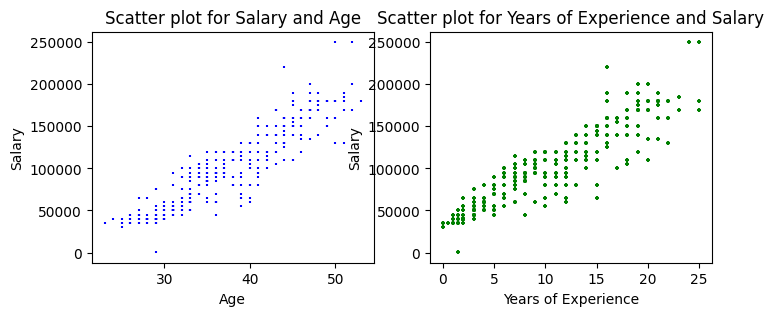

In [60]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.scatter(df['Age'], df['Salary'], marker = '|', s = 2, color = 'blue')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Scatter plot for Salary and Age')

plt.subplot(122)
plt.scatter(df['Years of Experience'], df['Salary'], marker = '+', s = 5, color = 'green')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Scatter plot for Years of Experience and Salary')
plt.show()

## Normalización

- Evita que una característica domine por su magnitud.  
- **Convergencia**: Mejora la optimización en redes y regresión por gradiente.  
- Esencial para PCA, LDA y regresión regularizada (relacionados con varianza).  
- Reduce overflow/underflow y errores de precisión.  
- **Interpretación**: Compara fácilmente coeficientes y pesos.

### Consideraciones para usar normalización
- Antes de algoritmos basados en distancia o gradiente.  
- Antes de PCA, LDA o regularización.  
- No necesario en árboles de decisión (Random Forest, XGBoost).  


In [62]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler

# Normalización Max

In [63]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)

max_scaler = MaxAbsScaler()
df[['Age', 'Salary']] = max_scaler.fit_transform(df[['Age', 'Salary']])

print("\nDataFrame normalizado Max:")
print(f"Max 'Age' normalizado: {df['Age'].max()}")
print(f"Max 'Age' original: {pd.read_csv('Salary Data.csv')['Age'].max()}")
df.head()

(375, 6)

DataFrame normalizado Max:
Max 'Age' normalizado: 1.0
Max 'Age' original: 53.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.603774,Male,Bachelor's,Software Engineer,5.0,0.36
1,0.528302,Female,Master's,Data Analyst,3.0,0.26
2,0.849057,Male,PhD,Senior Manager,15.0,0.60
3,0.679245,Female,Bachelor's,Sales Associate,7.0,0.24
4,0.981132,Male,Master's,Director,20.0,0.80


In [64]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)

df['Age'] = df['Age'] / df['Age'].abs().max()
df['Salary'] = df['Salary'] / df['Salary'].abs().max()

print("\nDataFrame normalizado Max:")
print(f"Max 'Age' normalizado: {df['Age'].max()}")
print(f"Max 'Age' original: {pd.read_csv('Salary Data.csv')['Age'].max()}")

df.head()

(375, 6)

DataFrame normalizado Max:
Max 'Age' normalizado: 1.0
Max 'Age' original: 53.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.603774,Male,Bachelor's,Software Engineer,5.0,0.36
1,0.528302,Female,Master's,Data Analyst,3.0,0.26
2,0.849057,Male,PhD,Senior Manager,15.0,0.60
3,0.679245,Female,Bachelor's,Sales Associate,7.0,0.24
4,0.981132,Male,Master's,Director,20.0,0.80


# Normalización Min-Max

In [65]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)

min_max_scaler = MinMaxScaler()
df[['Age', 'Salary']] = min_max_scaler.fit_transform(df[['Age', 'Salary']])

print("\nDataFrame normalizado Min-Max:")
print(f"Max 'Age' normalizado: {df['Age'].max()}")
print(f"Max 'Age' original: {pd.read_csv('Salary Data.csv')['Age'].max()}")
df.head()

(375, 6)

DataFrame normalizado Min-Max:
Max 'Age' normalizado: 1.0
Max 'Age' original: 53.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.300000,Male,Bachelor's,Software Engineer,5.0,0.359103
1,0.166667,Female,Master's,Data Analyst,3.0,0.258963
2,0.733333,Male,PhD,Senior Manager,15.0,0.599439
3,0.433333,Female,Bachelor's,Sales Associate,7.0,0.238935
4,0.966667,Male,Master's,Director,20.0,0.799720


In [66]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)

df['Age'] = (df['Age'] - df['Age'].min())/(df['Age'].max() - df['Age'].min())
df['Salary'] = (df['Salary'] - df['Salary'].min())/(df['Salary'].max() - df['Salary'].min())

print("\nDataFrame normalizado Max:")
print(f"Max 'Age' normalizado: {df['Age'].max()}")
print(f"Max 'Age' original: {pd.read_csv('Salary Data.csv')['Age'].max()}")
df.head()

(375, 6)

DataFrame normalizado Max:
Max 'Age' normalizado: 1.0
Max 'Age' original: 53.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.300000,Male,Bachelor's,Software Engineer,5.0,0.359103
1,0.166667,Female,Master's,Data Analyst,3.0,0.258963
2,0.733333,Male,PhD,Senior Manager,15.0,0.599439
3,0.433333,Female,Bachelor's,Sales Associate,7.0,0.238935
4,0.966667,Male,Master's,Director,20.0,0.799720


Selección automática de columnas numéricas

In [67]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)

min_max_scaler =  MinMaxScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = min_max_scaler.fit_transform(df[num_cols])

print("\nDataFrame normalizado Min-Max:")
print(f"Max 'Age' normalizado: {df['Age'].max()}")
print(f"Max 'Age' original: {pd.read_csv('Salary Data.csv')['Age'].max()}")
df.head()

(375, 6)

DataFrame normalizado Min-Max:
Max 'Age' normalizado: 1.0
Max 'Age' original: 53.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.300000,Male,Bachelor's,Software Engineer,0.20,0.359103
1,0.166667,Female,Master's,Data Analyst,0.12,0.258963
2,0.733333,Male,PhD,Senior Manager,0.60,0.599439
3,0.433333,Female,Bachelor's,Sales Associate,0.28,0.238935
4,0.966667,Male,Master's,Director,0.80,0.799720


# Normalización Z-score

In [68]:
df = pd.read_csv('Salary Data.csv')
print(df.shape)

scaler = StandardScaler()
df[['Age','Salary']] = scaler.fit_transform(df[['Age','Salary']])

print("\nDataFrame normalizado Max:")
print(f"Max 'Age' normalizado: {df['Age'].max()}")
print(f"Max 'Age' original: {pd.read_csv('Salary Data.csv')['Age'].max()}")
df.head()

(375, 6)

DataFrame normalizado Max:
Max 'Age' normalizado: 2.205278672919145
Max 'Age' original: 53.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,-0.769398,Male,Bachelor's,Software Engineer,5.0,-0.219559
1,-1.336003,Female,Master's,Data Analyst,3.0,-0.738498
2,1.072068,Male,PhD,Senior Manager,15.0,1.025892
3,-0.202793,Female,Bachelor's,Sales Associate,7.0,-0.842285
4,2.063627,Male,Master's,Director,20.0,2.063768


## Ejercicio:

1. Importar el archivo `Salary Data.csv` a un DataFrame de pandas.
2. Investigar la fórmula matemática para la transformación Z-score.
3. Filtrar el DataFrame para mantener solo las columnas de tipo numérico.
4. Aplicar normalización Z-score.
5. Para el DataFrame estandarizado, calcular y mostrar **media** y **desviación estándar** de cada característica.

In [70]:
# z-score
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


Explique la diferencia entre los métodos de normalización vistos e investigue en qué situaciones sería más apropiado usar uno en lugar de los otros.

# Distribuciones

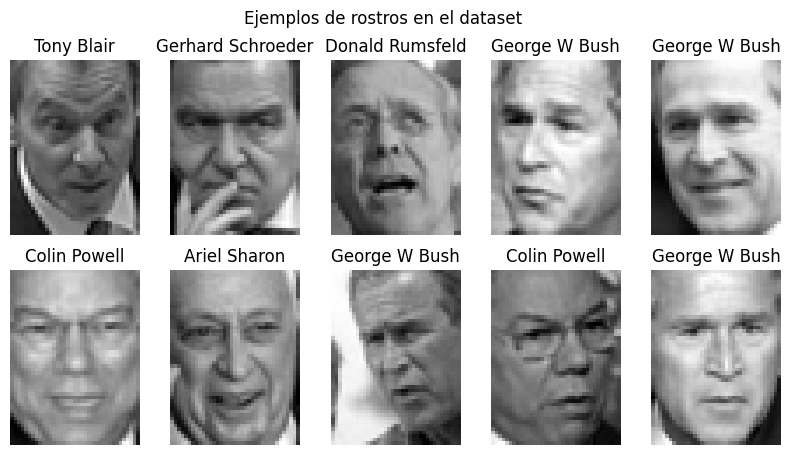

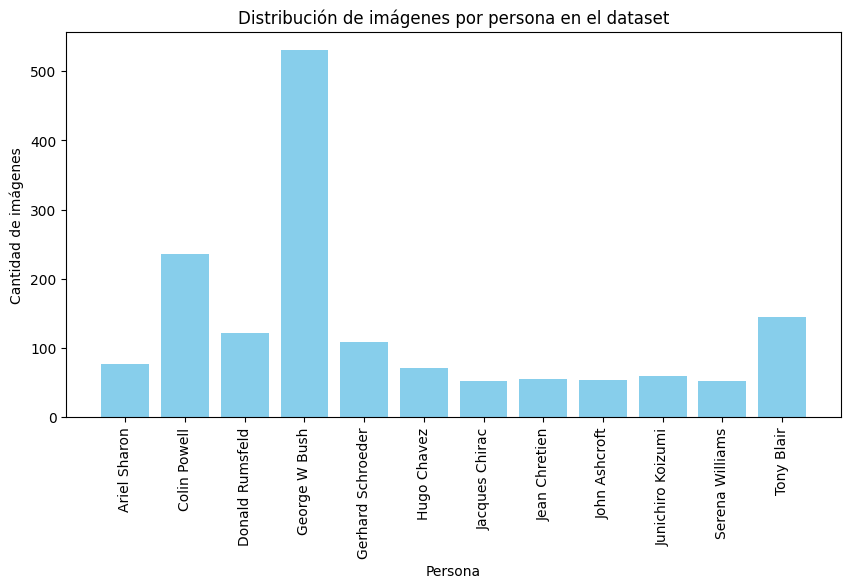

In [639]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people


lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=0.4)

images = lfw_people.images
targets = lfw_people.target
target_names = lfw_people.target_names


fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(target_names[targets[i]])
    ax.axis("off")
plt.suptitle("Ejemplos de rostros en el dataset")
plt.show()

unique, counts = np.unique(targets, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(target_names[unique], counts, color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Persona")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por persona en el dataset")
plt.show()

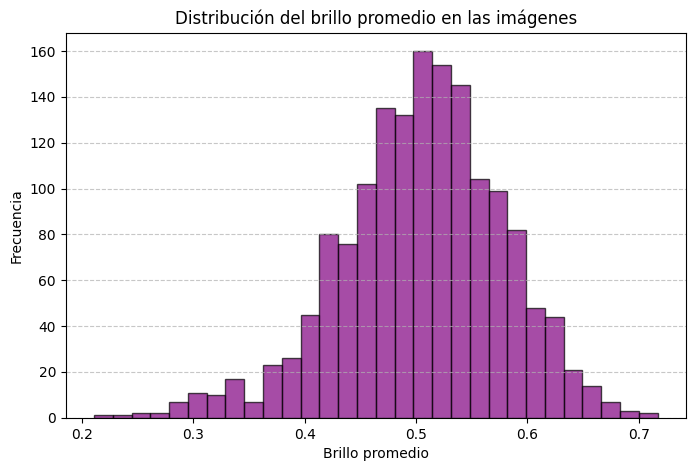

In [640]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=0.4)


images = lfw_people.images

brightness_values = [np.mean(img) for img in images]

plt.figure(figsize=(8, 5))
plt.hist(brightness_values, bins=30, color="purple", alpha=0.7, edgecolor="black")
plt.xlabel("Brillo promedio")
plt.ylabel("Frecuencia")
plt.title("Distribución del brillo promedio en las imágenes")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


# Actividades

## Hallazgos mediante condicionales

Una empresa de seguros marítimos está estudiando el perfil de los pasajeros involucrados en accidentes de esta índole para comprender factores de riesgo asociados a viajes marítimos. Se te hace entrega de un dataset para extraer información útil.

- Realizar una exploración inicial para tener bases sobre las cuales realizar el análisis.
  - Ejemplo: El viaje contaba con 102 pasajeros, los cuales pueden dividirse en rangos etarios.
- Construir `loc` condicionales que permitan establecer relaciones entre el deceso o la supervivencia de los pasajeros.
  - Ejemplo: Relación entre la edad de los pasajeros y su estado.
- Redactar un total de 3 observaciones o conclusiones que muestren hallazgos sobre el tema de estudio.
  - Ejemplo: 42% de los decesos corresponden a personas de la tercera edad (mayores a 65 años).
- Añadir a cada observación una hipótesis que pueda servir como posible causa.
  - Ejemplo: El porcentaje podría atribuirse a la incentiva de "niños y mujeres primero", que naturalmente crea un orden de prioridad.

In [641]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Normalización vectorial usando arrays

### Contexto

Hasta ahora hemos aplicado normalización variable por variable usando operaciones sobre columnas de un DataFrame con pandas.

In [642]:
df = sns.load_dataset("titanic")

df["age_norm"] = (df["age"] - df["age"].min()) / (df["age"].max() - df["age"].min())
df["fare_norm"] = (df["fare"] - df["fare"].min()) / (df["fare"].max() - df["fare"].min())

Otra alternativa es usar un loop para aplicar la misma operación a varias columnas:

In [643]:
df = sns.load_dataset("titanic")

for col in ["age", "fare"]:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

Este enfoque funciona, pero presenta algunas limitaciones:

- Debemos iterar explícitamente sobre las columnas.
- El código depende de nombres de columnas específicos.
- No aprovecha completamente las operaciones vectorizadas.

En ciencia de datos es común representar los datasets como matrices numéricas, donde las filas corresponden a observaciones y las columnas a variables.

Muchas bibliotecas trabajan internamente con arrays de NumPy en lugar de DataFrames. Trabajar con matrices permite aplicar operaciones sobre múltiples variables al mismo tiempo.

### Ejercicio

Convierte las variables numéricas `age` y `fare` en un array de NumPy. A continuación, utiliza `axis=0` para aplicar normalización simultáneamente a ambas variables. Repite para normalización Min-Max y Z-score.

**Consideración:** Antes de aplicar operaciones matemáticas a los datos, verifica si existen valores faltantes (NaN). Si un valor NaN participa en un cálculo matemático, el resultado también será NaN.

In [645]:
df = sns.load_dataset("titanic")

X = df[["age", "fare"]].to_numpy()

# completar

¿Qué ocurriría si en lugar de `axis=0` utilizamos `axis=1` al calcular los mínimos y máximos?

Investiga por qué usar operaciones vectorizadas con arrays es más eficiente que aplicar la normalización fila por fila en un loop.